In [1]:
import os
os.chdir("..")
print(os.getcwd())

c:\Users\NASA2004\OneDrive\Documents\transformer-from-scratch


In [2]:
# positional encoding
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [3]:
# verifying
pe_layer = PositionalEncoding(d_model=512)
dummy = torch.zeros(2, 10, 512)
out = pe_layer(dummy)
print(out.shape)

torch.Size([2, 10, 512])


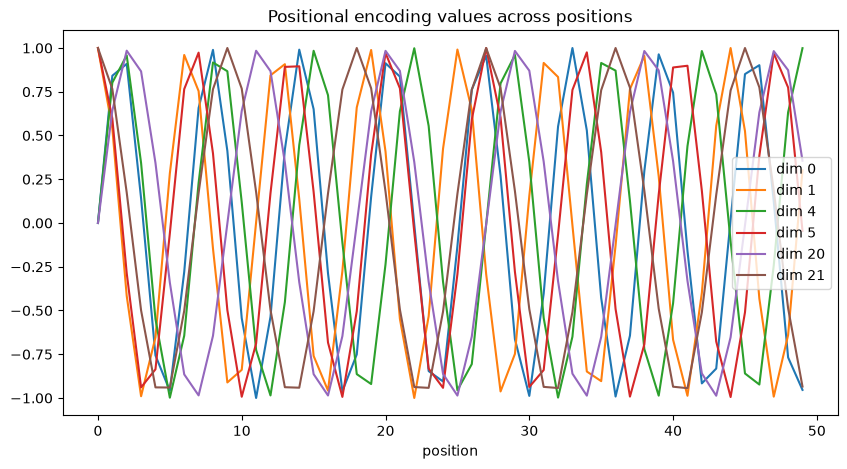

In [5]:
# plotting

import matplotlib.pyplot as plt
pe = pe_layer.pe[0, :50, :].numpy()
plt.figure(figsize=(10, 5))
for dim in [0, 1, 4, 5, 20, 21]:
    plt.plot(pe[:, dim], label=f"dim {dim}")
plt.legend()
plt.xlabel("position")
plt.title("Positional encoding values across positions")
plt.savefig("figures/positional_encoding.png")
plt.show()

In [6]:
# testing the import from src

import sys
from src.positional_encoding import PositionalEncoding